### **Predictive IT Infrastructure Analytics**

#### **Data Insights and Pattern Analysis (Análisis de resultados, patrones y conclusiones obtenidas de los datos ya preparados y transformados)**

##### **Objetivo del Notebook**

##### El objetivo de este notebook es profundizar en el análisis de las métricas de rendimiento y estabilidad de la infraestructura IT a partir del dataset previamente preparado y transformado.

##### Durante esta etapa se estudiarán las relaciones entre las variables operativas del sistema y el estado de funcionamiento registrado, identificando patrones, tendencias e indicadores que puedan estar asociados a situaciones de degradación, sobrecarga o fallo. Asimismo, se evaluará el comportamiento de las variables derivadas generadas durante la fase de preparación de datos para determinar su utilidad en futuros modelos predictivos.

##### (The objective of this notebook is to perform an in-depth analysis of IT infrastructure performance and stability metrics using the previously prepared and transformed dataset.

##### This stage focuses on identifying patterns, trends, and relationships between operational system metrics and the recorded system status. Special attention is given to the derived features created during the data preparation phase in order to evaluate their potential contribution to future predictive models.)

### **Fase 6. Análisis exploratorio avanzado / EDA**
### **1. Importación de librerías**

In [1]:
import pandas as pd # Librería para trabajar con datos en forma de tablas
import numpy as np # Librería para operaciones numéricas
import matplotlib.pyplot as plt # Librería para crear gráficos
import seaborn as sns # Librería para visualizaciones más elaboradas
import os # Permite trabajar con rutas y carpetas del sistema

# Inicializamos un DataFrame vacío
df = pd.DataFrame()

# Configuración visual
plt.style.use("default")
pd.set_option("display.max_columns", None)

# Creación de ruta de guardado de gráficos generados
ruta_graficos = "../reports/graphics"
os.makedirs(ruta_graficos, exist_ok=True)

### **2. Carga del DataSet transformado**

In [2]:
# Cargar datasets
df = pd.read_csv("../data/processed/Big_data_dataset_transformado.csv")

# Mostrar las primeras filas del DataFrame
df.head()

,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status,status_label,cpu_level,memory_level,latency_level,temperature_level,cpu_utilization_norm,memory_usage_norm,network_latency_norm,temperature_norm,power_consumption_norm,system_pressure_score,pressure_level
0,40.581311,43.627674,36.769917,127.990769,646,3230,1500,0.065837,82.782403,255.012964,715.803096,0,Normal,Medium,Low,High,Critical,0.374639,0.373570,0.638277,0.812102,0.820130,0.603744,Medium
1,95.317859,39.962089,10.041088,92.399198,626,3130,243,0.123481,59.424540,81.204822,86.158314,0,Normal,High,Low,Medium,Warning,0.950982,0.332832,0.459386,0.452671,0.124683,0.464111,Medium
2,74.539424,25.853852,17.985345,192.935206,101,303,229,0.025459,90.973363,210.685067,545.755982,0,Normal,High,Low,High,Critical,0.732198,0.176037,0.964702,0.938145,0.642764,0.690769,High
3,61.872556,64.654000,33.500751,44.576712,52,156,1574,0.178884,37.344280,90.398182,541.918137,0,Normal,Medium,Medium,Low,Normal,0.598823,0.607250,0.219020,0.112899,0.161467,0.339892,Medium
4,19.821771,52.896174,24.622378,117.983427,126,378,1164,0.167508,40.203942,87.099085,113.660688,0,Normal,Low,Medium,High,Normal,0.156053,0.476577,0.587978,0.156903,0.148267,0.305156,Low


### **3. Verificación del dataset**

In [3]:
# Mostrar la forma del DataFrame
print(df.shape)

(10000, 24)


In [4]:
# Mostrar información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cpu_utilization         10000 non-null  float64
 1   memory_usage            10000 non-null  float64
 2   disk_io                 10000 non-null  float64
 3   network_latency         10000 non-null  float64
 4   process_count           10000 non-null  int64  
 5   thread_count            10000 non-null  int64  
 6   context_switches        10000 non-null  int64  
 7   cache_miss_rate         10000 non-null  float64
 8   temperature             10000 non-null  float64
 9   power_consumption       10000 non-null  float64
 10  uptime                  10000 non-null  float64
 11  status                  10000 non-null  int64  
 12  status_label            10000 non-null  str    
 13  cpu_level               10000 non-null  str    
 14  memory_level            10000 non-null  str    
 1

### **4. Distribución del estado del sistema**

In [5]:
# Mostrar los primeros registros del DataFrame
df["status_label"].value_counts()

status_label
Normal      9903
Incident      97
Name: count, dtype: int64

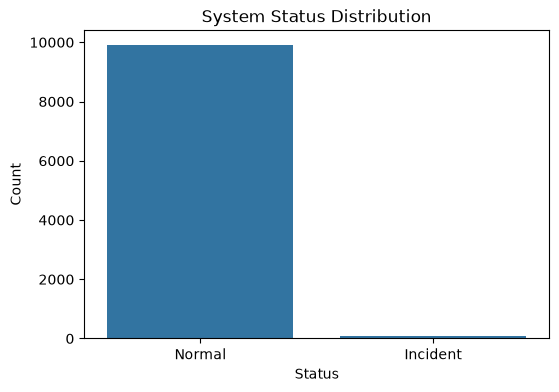

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
plt.figure(figsize=(6,4))

# Crea un gráfico de conteo para mostrar la distribución de estados del sistema
sns.countplot(
    data=df,
    x="status_label"
)

# Guarda Gráfico de las distribuciones con valores en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_04_distribucion_estado_sistema.png", dpi=300, bbox_inches="tight")

# Imprime el título y las etiquetas de los ejes
plt.title("System Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

# Muestra el gráfico
plt.show()

### **5. Variables más relacionadas con el estado del sistema**

In [7]:
# Calcula las correlaciones entre todas las columnas numéricas y la columna "status"
correlaciones = (
    df.corr(numeric_only=True)["status"]
    .sort_values(ascending=False)
)

# Crea un DataFrame a partir de las correlaciones y resetea el índice
correlaciones

status                    1.000000
system_pressure_score     0.174365
memory_usage              0.140458
memory_usage_norm         0.140458
cpu_utilization_norm      0.136265
cpu_utilization           0.136265
temperature_norm          0.116836
temperature               0.116836
context_switches          0.014649
uptime                    0.010158
power_consumption_norm    0.003681
power_consumption         0.003681
cache_miss_rate           0.003420
thread_count              0.001346
process_count             0.000598
network_latency_norm     -0.009552
network_latency          -0.009552
disk_io                  -0.009892
Name: status, dtype: float64

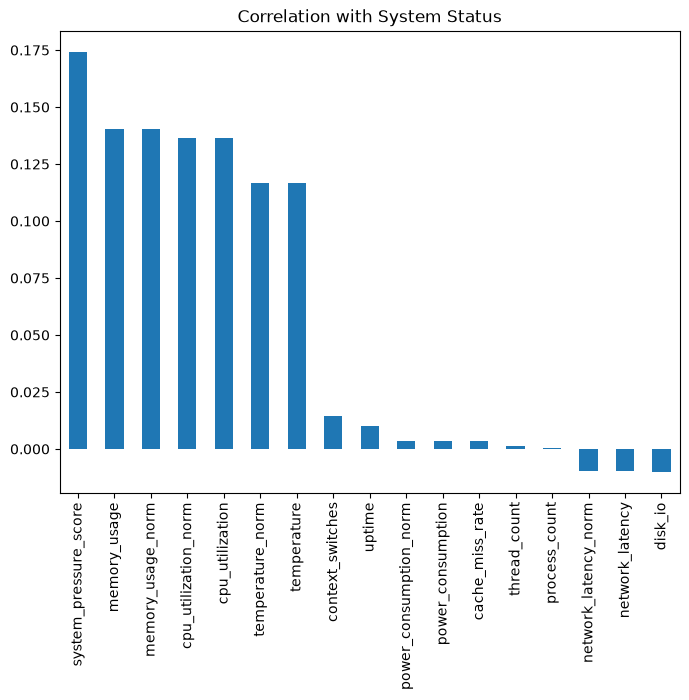

In [ ]:
# Crea un gráfico de barras para mostrar las correlaciones con el estado del sistema
plt.figure(figsize=(8,6))

# Correlaciones con el estado del sistema, excluyendo la propia columna "status"
correlaciones.drop("status").plot(
    kind="bar"
)

# Guarda Gráfico de las correlaciones relacionadas con el estado del sistema en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_05_correlacion_con_status.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico (Correlación con estatus del sistema)
plt.title("Correlation with System Status")

# Muestra el gráfico
plt.show()

### **6. Análisis de CPU y fallos**

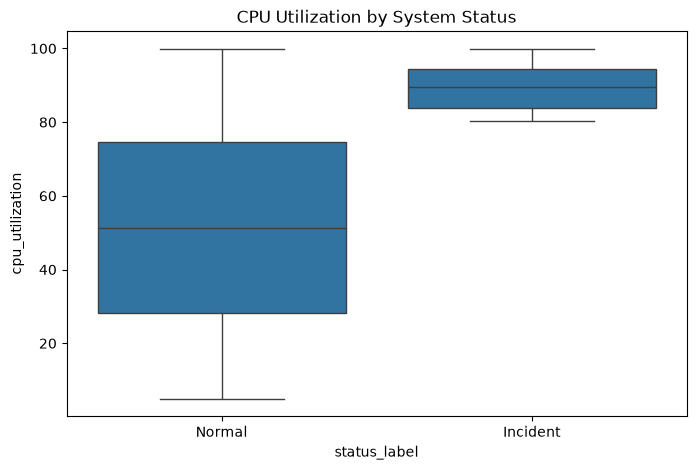

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
plt.figure(figsize=(8,5))

# Crea un gráfico de caja para mostrar la distribución de la utilización de CPU por estado del sistema
sns.boxplot(
    data=df,
    x="status_label",
    y="cpu_utilization"
)

# Guarda Gráfico de las correlaciones del status relacionadas con el estado del sistema en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_06_cpu_por_estado.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico
plt.title("CPU Utilization by System Status")

# Muestra el gráfico
plt.show()

### **7. Análisis de Memoria y fallos**

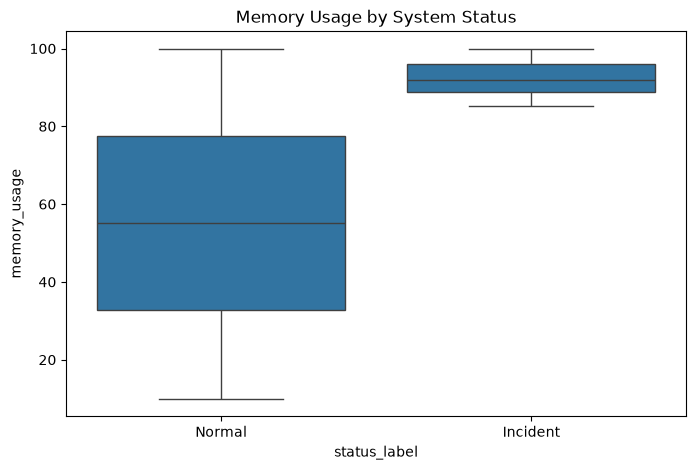

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
plt.figure(figsize=(8,5))

# Crea un gráfico de caja para mostrar la distribución de la utilización de memoria por estado del sistema
sns.boxplot(
    data=df,
    x="status_label",
    y="memory_usage"
)

# Guarda Gráfico de la la distribución de la utilización de memoria en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_07_memoria_por_estado.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico
plt.title("Memory Usage by System Status")

# Muestra el gráfico
plt.show()

### **8. Análisis de Temperatura y fallos**

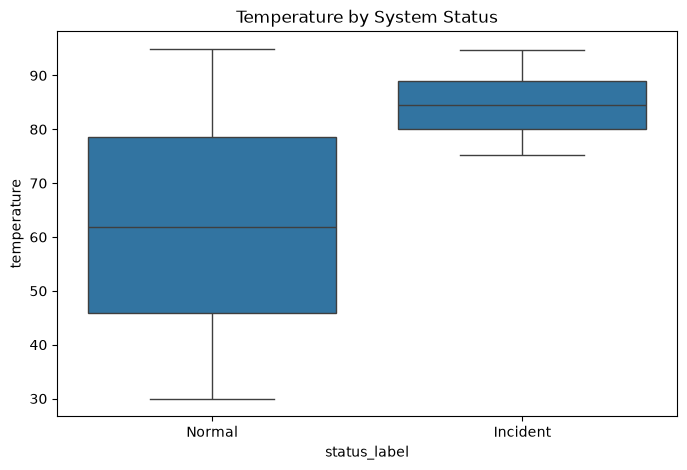

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
plt.figure(figsize=(8,5))

# Crea un gráfico de caja para mostrar la distribución de la temperatura por estado del sistema
sns.boxplot(
    data=df,
    x="status_label",
    y="temperature"
)

# Guarda Gráfico de la la distribución de la temperatura por estado del sistema en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_08_temperatura_por_estado.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico
plt.title("Temperature by System Status")

# Muestra el gráfico
plt.show()

### **Fase 7. Insights y patrones**
### **9. Evaluación de variables derivadas**

In [12]:
# Crea una tabla de contingencia para mostrar la relación entre el nivel de CPU y el estado del sistema
pd.crosstab(
    df["cpu_level"],
    df["status_label"]
)

status_label,Incident,Normal
cpu_level,,
High,97,2953
Low,0,3738
Medium,0,3212


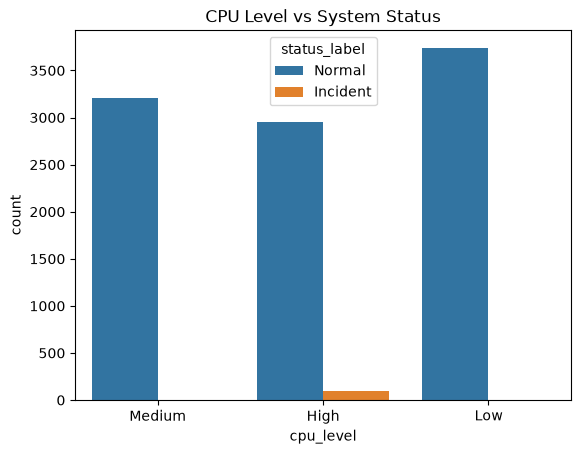

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
sns.countplot(
    data=df,
    x="cpu_level",
    hue="status_label"
)

# Guarda Gráfico de la la distribución las variables derivadas 'cpu_level' y 'status_label'
# en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_09_cpu_level_vs_status.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico
plt.title("CPU Level vs System Status")

# Muestra el gráfico
plt.show()

### **10. Evaluación de Temperature Level**

In [14]:
# Crea una tabla de contingencia para mostrar la relación entre el nivel de temperatura y el estado del sistema
pd.crosstab(
    df["temperature_level"],
    df["status_label"]
)

status_label,Incident,Normal
temperature_level,,
Critical,97,3698
Normal,0,3104
Warning,0,3101


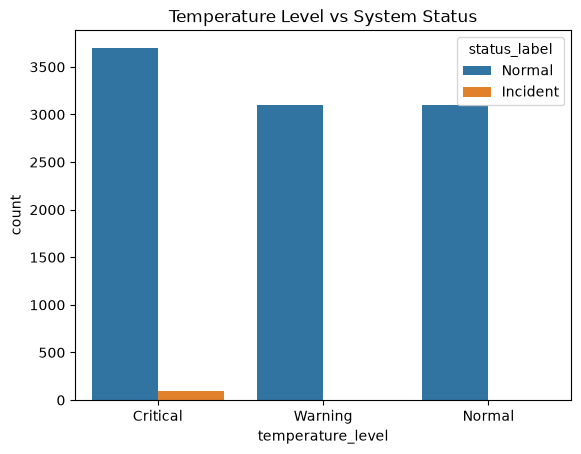

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
sns.countplot(
    data=df,
    x="temperature_level",
    hue="status_label"
)

# Guarda Gráfico de la la distribución las variables derivadas 'temperature_level' y 'status_label'
# en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_10_temperature_level_vs_status.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico
plt.title("Temperature Level vs System Status")

# Muestra el gráfico
plt.show()

### **11. Evaluación de Pressure Level**

In [16]:
# Crea una tabla de contingencia para la presión y el estado del sistema
pd.crosstab(
    df["pressure_level"],
    df["status_label"]
)

status_label,Incident,Normal
pressure_level,,
High,79,1022
Low,0,965
Medium,18,7916


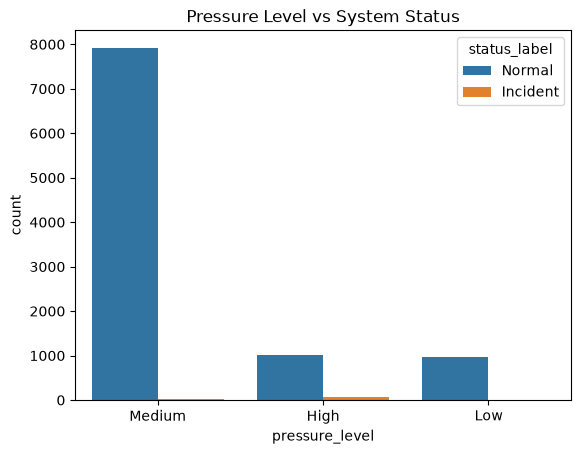

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
sns.countplot(
    data=df,
    x="pressure_level",
    hue="status_label"
)

# Guarda Gráfico de la la distribución las variables derivadas 'pressure_level' y 'status_label'
# en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_11_pressure_level_vs_status.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico
plt.title("Pressure Level vs System Status")

# Muestra el gráfico
plt.show()

### **12. Análisis del System Pressure Score**

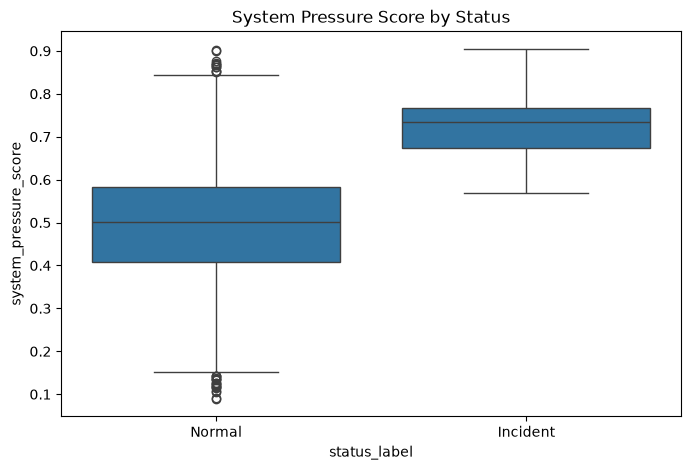

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
plt.figure(figsize=(8,5))

# Crea un gráfico de caja para mostrar la distribución de la puntuación de presión del sistema por estado del sistema
sns.boxplot(
    data=df,
    x="status_label",
    y="system_pressure_score"
)

# Guarda Gráfico de la distribución las variables derivadas 'system_pressure_score' y 'status_label'
# en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_12_system_pressure_score_por_estado.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico
plt.title("System Pressure Score by Status")

# Muestra el gráfico
plt.show()

### **13. Matriz de correlación avanzada**

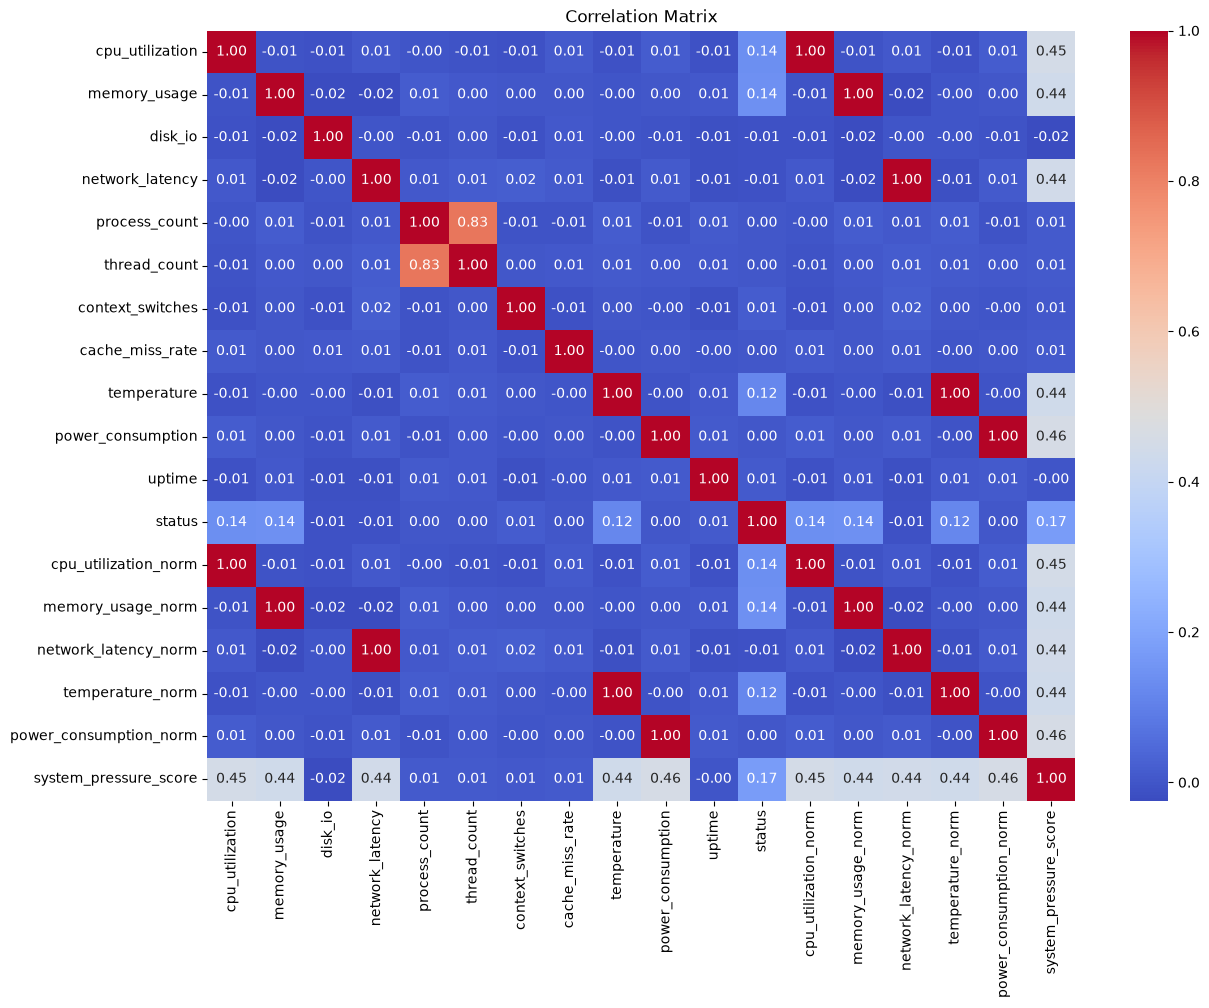

In [ ]:
# Delimita el tamaño de la figura para que se ajuste a la visualización
plt.figure(figsize=(14,10))

# Crea un mapa de calor para mostrar la matriz de correlación entre las columnas numéricas del DataFrame
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Guarda Gráfico de la matríz de correlación avanzada en la carpeta /graficos del proyecto
plt.savefig(f"{ruta_graficos}/Nb03_13_matriz_correlacion_avanzada.png", dpi=300, bbox_inches="tight")

# Imprime el título del gráfico
plt.title("Correlation Matrix")

# Muestra el gráfico
plt.show()

### **14. Análisis de la Matríz de Correlación**
El análisis permitió identificar que CPU, memoria y temperatura son las métricas más asociadas a situaciones de degradación o fallo del sistema.

Las variables derivadas creadas durante la fase de preparación aportan una visión más interpretable del comportamiento de la infraestructura, facilitando la identificación de patrones operativos y posibles escenarios de riesgo.

Los resultados obtenidos respaldan la utilización de este conjunto de datos para futuras tareas de monitorización inteligente y modelado predictivo dentro de entornos IT.

### **15. Insights obtenidos**

### **Insights Principales**

#### **Insight 1**
Las variables CPU Utilization, Memory Usage y Temperature presentan la relación más relevante con el estado del sistema.

### **Insight 2**
Los sistemas con incidencias muestran valores superiores de presión operativa respecto a los sistemas normales.

### **Insight 3**
Las variables derivadas permiten segmentar de forma más clara los niveles de riesgo y rendimiento.

### **Insight 4**
El indicador compuesto System Pressure Score resume adecuadamente el nivel general de carga del sistema.

### **Insight 5**
El dataset presenta características adecuadas para la construcción de modelos predictivos orientados a la detección temprana de anomalías.

### **16. Conclusiones a partir del los Insights obtenidos**

El análisis permitió identificar que CPU, memoria y temperatura son las métricas más asociadas a situaciones de degradación o fallo del sistema.

Las variables derivadas creadas durante la fase de preparación aportan una visión más interpretable del comportamiento de la infraestructura, facilitando la identificación de patrones operativos y posibles escenarios de riesgo.

Los resultados obtenidos respaldan la utilización de este conjunto de datos para futuras tareas de monitorización inteligente y modelado predictivo dentro de entornos IT.

### **17. Tareas completadas en este notebook:**

##### **A. Carga y configuración del entorno de trabajo**
- Importación de librerías para análisis y visualización de datos:
  - Pandas
  - NumPy
  - Matplotlib
  - Seaborn
- Configuración de opciones de visualización.
- Inicialización del entorno de análisis.

##### **B. Carga del dataset transformado**
- Lectura del archivo procesado `Big_data_dataset_transformado.csv`.
- Verificación de la correcta carga de los datos.
- Visualización preliminar de los registros.

##### **C. Validación de la estructura del dataset**
- Comprobación del número de filas y columnas.
- Revisión de tipos de datos.
- Verificación general de la información del dataset.

##### **D. Análisis de la distribución del estado del sistema**
- Evaluación de la frecuencia de cada estado operativo.
- Generación de gráfico de distribución de estados.
- Identificación del nivel de desbalance entre sistemas normales e incidentes.

##### **E. Identificación de variables relacionadas con el estado del sistema**
- Cálculo de correlaciones entre variables numéricas y la variable objetivo.
- Ordenación de variables según su nivel de asociación con los incidentes.
- Visualización de las correlaciones mediante gráfico de barras.

##### **F. Análisis de CPU y estado del sistema**
- Comparación del consumo de CPU entre sistemas normales y sistemas con incidencias.
- Visualización mediante diagramas de caja.
- Identificación de diferencias en la utilización de CPU.

##### **G. Análisis de memoria y estado del sistema**
- Evaluación del uso de memoria según el estado operativo.
- Comparación de distribuciones mediante boxplots.
- Detección de patrones asociados a incidencias.

##### **H. Análisis de temperatura y estado del sistema**
- Estudio del comportamiento térmico de la infraestructura.
- Comparación entre sistemas normales y sistemas degradados.
- Evaluación de la influencia de la temperatura sobre los fallos.

##### **I. Evaluación de la variable derivada CPU Level**
- Construcción de tablas de contingencia.
- Análisis de la relación entre niveles de CPU y estado del sistema.
- Visualización de frecuencias mediante gráficos categóricos.

##### **J. Evaluación de la variable derivada Temperature Level**
- Análisis de la clasificación térmica creada durante la preparación de datos.
- Comparación de categorías de temperatura con el estado operativo.
- Identificación de niveles potencialmente asociados a incidencias.

##### **K. Evaluación de la variable derivada Pressure Level**
- Estudio de los niveles de presión operativa.
- Relación entre presión del sistema y aparición de fallos.
- Visualización de patrones mediante gráficos de conteo.

##### **L. Análisis del indicador compuesto System Pressure Score**
- Evaluación del comportamiento del índice de presión global.
- Comparación entre sistemas normales e incidentes.
- Validación de su capacidad para resumir la carga operativa del sistema.

##### **M. Construcción de la matriz de correlación avanzada**
- Cálculo de correlaciones entre todas las variables numéricas.
- Generación de mapa de calor.
- Identificación de relaciones fuertes, moderadas y débiles entre métricas.

##### **N. Interpretación de resultados analíticos**
- Identificación de CPU, memoria y temperatura como variables más relacionadas con el estado del sistema.
- Evaluación de la utilidad de las variables derivadas.
- Análisis del comportamiento general de la infraestructura IT.

##### **Ñ. Generación de insights de negocio y operativos**
- Identificación de los principales factores asociados a incidencias.
- Evaluación del nivel de presión operativa de los sistemas.
- Valoración del potencial predictivo de las variables creadas.
- Determinación de indicadores clave para monitorización futura.

##### **O. Elaboración de conclusiones de los hallazgos obtenidos**
- Consolidación de los hallazgos obtenidos durante el análisis.
- Validación de la relevancia de las variables seleccionadas.
- Confirmación de la utilidad del dataset para futuros modelos predictivos.
- Obtención de conocimiento accionable para tareas de monitorización inteligente y detección temprana de anomalías.